# 02 — Exploratory Data Analysis (EDA)

**Sentimentanalys av flygbolagstweets — steg 2/6**

Här utforskar vi datan och bygger den databerättelse som används i presentationen.
Kräver bara `data/full_clean.csv` från **01_data_preparation.ipynb** — ingen internetuppkoppling
till Hugging Face behövs här, så den här notebooken går att köra vart som helst.


### Working directory

VS Code runs notebooks with the **notebook's own folder** as the working directory by
default, while Colab uses whichever folder you're in when you open it. The cell below
makes sure we always end up at the **project root**, so `data/`, `charts/`, and
`models/` land in the right place regardless of how you launched this notebook.


In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Working directory:", os.getcwd())


Working directory: c:\Users\anoth\dev\AIkurs-statistik\airline-sentiment-transfer-learning


## Imports & data

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 12})

os.makedirs("charts", exist_ok=True)

df = pd.read_csv("data/full_clean.csv", encoding="utf-8")
print(df.shape)
df.head(3)


(14640, 4)


,text,airline_sentiment,airline,negativereason
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America,NaN
1,@VirginAmerica plus you've added commercials t...,positive,Virgin America,NaN
2,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America,NaN


**Vad output visar:** `(14640, 4)` bekräftar att hela det städade datasetet från
notebook 01 laddats in korrekt (4 kolumner: text, airline_sentiment, airline,
negativereason). Om formen ser annorlunda ut, kontrollera att `01_data_preparation.ipynb`
verkligen körts i samma session först.


## Sentimentfördelning överlag

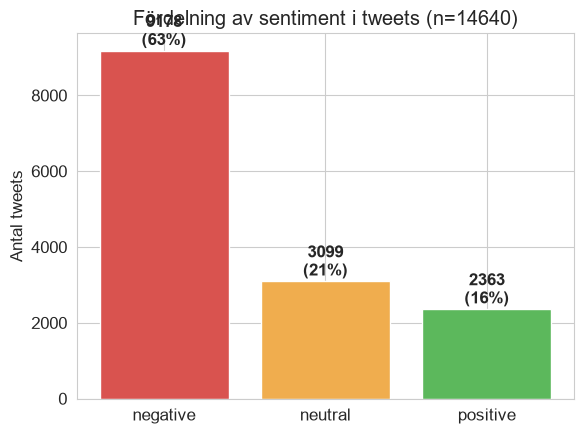

In [3]:
order = ["negative", "neutral", "positive"]
colors = ["#d9534f", "#f0ad4e", "#5cb85c"]

fig, ax = plt.subplots(figsize=(6, 4.5))
counts = df["airline_sentiment"].value_counts().reindex(order)
ax.bar(order, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 150, f"{v}\n({v/len(df)*100:.0f}%)", ha="center", fontweight="bold")
ax.set_title(f"Fördelning av sentiment i tweets (n={len(df)})")
ax.set_ylabel("Antal tweets")
plt.tight_layout()
plt.savefig("charts/sentiment_distribution.png", dpi=150)
plt.show()


**Vad diagrammet visar:** tre staplar — negative, neutral, positive — med antal och
procentandel ovanpå. Den röda (negative) stapeln är ungefär **fyra gånger så hög** som den
gröna (positive) — det är den viktigaste enskilda observationen i hela projektet: flygbolag
hör nästan bara ifrån missnöjda kunder på Twitter. Diagrammet sparas också som
`charts/sentiment_distribution.png` för att kunna återanvändas i presentationen.


## Sentiment per flygbolag

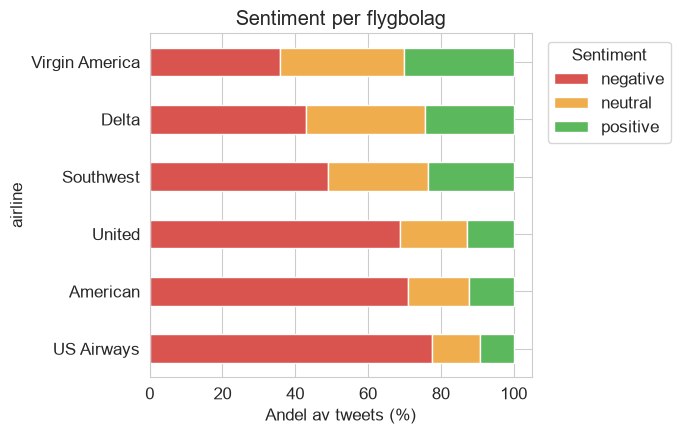

airline_sentiment,negative,neutral,positive
airline,,,
US Airways,78.0,13.0,9.0
American,71.0,17.0,12.0
United,69.0,18.0,13.0
Southwest,49.0,27.0,24.0
Delta,43.0,33.0,24.0
Virgin America,36.0,34.0,30.0


In [4]:
tab = (df.groupby("airline")["airline_sentiment"]
         .value_counts(normalize=True)
         .unstack()
         .reindex(columns=order)) * 100
tab = tab.sort_values("negative", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
tab.plot(kind="barh", stacked=True, color=colors, ax=ax)
ax.set_xlabel("Andel av tweets (%)")
ax.set_title("Sentiment per flygbolag")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("charts/sentiment_by_airline.png", dpi=150)
plt.show()

tab.round(0)


**Vad diagrammet visar:** en horisontell stapel per flygbolag, uppdelad i andel
negativa/neutrala/positiva tweets, sorterat så att flygbolaget med **mest** negativt sentiment
ligger längst ner. Tabellen under diagrammet ger samma sak i sifferform (procent per rad).
Lägg märke till spridningen: **US Airways** ligger runt 78% negativt medan **Virgin America**
ligger runt 36% — mer än dubbelt så bra, trots att båda flyger i samma marknad.


## Vanligaste orsakerna till negativa tweets

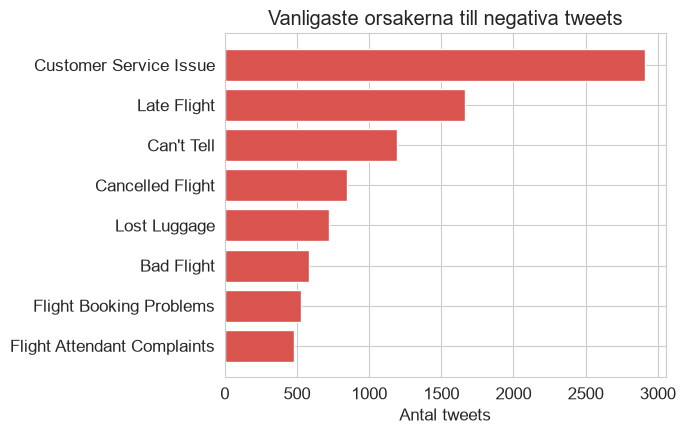

In [5]:
reasons = df["negativereason"].value_counts().head(8).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(reasons.index, reasons.values, color="#d9534f")
ax.set_title("Vanligaste orsakerna till negativa tweets")
ax.set_xlabel("Antal tweets")
plt.tight_layout()
plt.savefig("charts/top_negative_reasons.png", dpi=150)
plt.show()


**Vad diagrammet visar:** de åtta vanligaste värdena i kolumnen `negativereason`, sorterade
efter frekvens. **Customer Service Issue** och **Late Flight** dominerar stort — tillsammans
står de för en betydande andel av alla negativa tweets. Dessa är konkreta, åtgärdbara
kategorier, vilket är precis vad som gör dem intressanta att klassificera automatiskt i
notebook 05.


## Textlängd

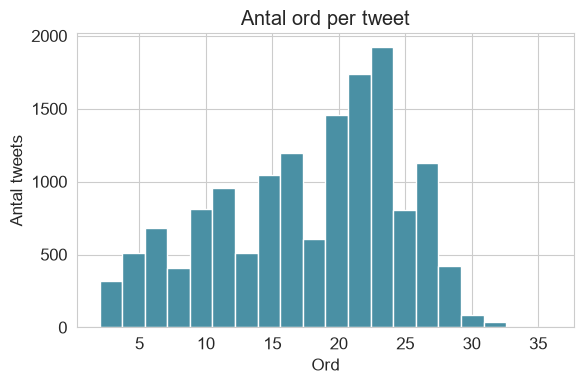

count    14640.000000
mean        17.653415
std          6.882259
min          2.000000
25%         12.000000
50%         19.000000
75%         23.000000
max         36.000000
Name: text, dtype: float64

In [6]:
lengths = df["text"].str.split().apply(len)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(lengths, bins=20, color="#4A90A4")
ax.set_title("Antal ord per tweet")
ax.set_xlabel("Ord")
ax.set_ylabel("Antal tweets")
plt.tight_layout()
plt.savefig("charts/text_length.png", dpi=150)
plt.show()

lengths.describe()


**Vad output visar:** histogrammet visar att de flesta tweets ligger mellan ~10 och ~25 ord,
med en topp runt Twitters gamla 140-teckensgräns. `describe()`-tabellen ger exakta siffror —
lägg särskilt märke till **median** (typiskt ~19 ord) och **max**. Detta är anledningen till
att vi senare väljer `MAX_LEN = 64` tokens vid tokenisering i notebook 03–05: det räcker
gott och gott för nästan alla tweets, utan att slösa beräkningstid på onödig padding.


## Insikter — databerättelsen

- **~63% av alla tweets är negativa**, bara 16% positiva — sociala medier fungerar i
  praktiken som en ostrukturerad, missnöjesdominerad kundtjänstkö.
- **US Airways, United och American** har klart sämst sentiment (69–78% negativt) medan
  **Virgin America och Delta** ligger bättre till (36–43% negativt).
- Vanligaste klagomålen: **Customer Service Issue**, **Late Flight** och **Cancelled Flight**
  — tre konkreta, åtgärdbara kategorier. Dessa återanvänds som klasser i notebook 05.
- Tweets är korta (median ~19 ord) — motiverar en kort `MAX_LEN` vid tokenisering längre fram.

Alla diagram är sparade i `./charts/` för återanvändning i presentationen.

**Nästa steg:** öppna `03_unsupervised_clustering.ipynb`.
